# Emotion Detection - Using Deep Face

In [6]:
# pip install deepface

In [9]:
# !ls face_recog*.ipynb

In [2]:
# import os
import glob
# import numpy

# print("Working Directory:", os.getcwd())
print("PKL files in ./data:", glob.glob("./data/*.pkl"))


PKL files in ./data: ['./data/emotion_analysis.pkl', './data/known_embeddings.pkl', './data/known_embeddings_emotion.pkl', './data/test_embedding.pkl', './data/test_embedding_emotion.pkl']


fear
{'angry': 1.549153447151184, 'disgust': 4.2580435888339707e-07, 'fear': 73.611572265625, 'happy': 2.1651110649108887, 'sad': 0.00013121614756528288, 'surprise': 22.674030303955078, 'neutral': 9.500937814266308e-09}
     angry: 1.55%
   disgust: 0.00%
      fear: 73.61%
     happy: 2.17%
       sad: 0.00%
  surprise: 22.67%
   neutral: 0.00%


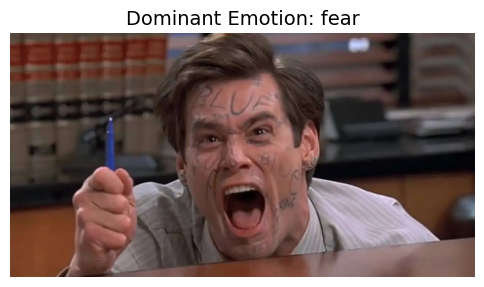

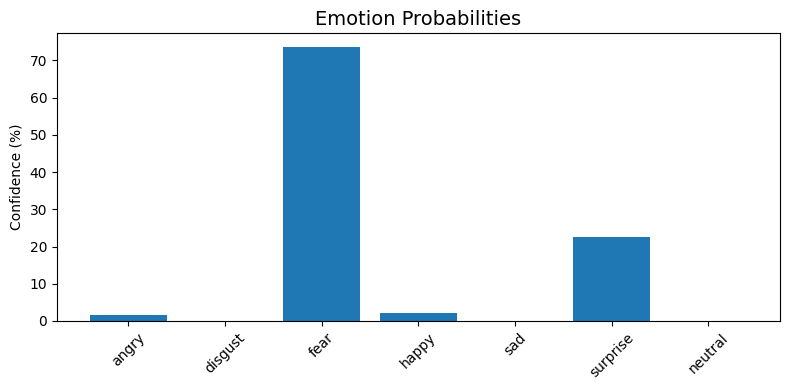

CPU times: user 997 ms, sys: 305 ms, total: 1.3 s
Wall time: 817 ms


In [2]:
%%time

# from deepface import DeepFace
import cv2
import matplotlib.pyplot as plt
import numpy
import pickle

# Load and analyze the image
# img_path = "./data/happy_person.jpeg"
img_path = "angry_face_1.jpg"

with open("emotion_analysis_cleaned.pkl", "rb") as f:
    loaded_analysis = pickle.load(f)

print(loaded_analysis["dominant_emotion"])
print(loaded_analysis["emotion"])  # dict of emotions

# Extract emotion results
emotions = loaded_analysis["emotion"]
dominant = loaded_analysis["dominant_emotion"]

for emo, score in emotions.items():
    print(f"{emo:>10}: {score:.2f}%")

# Display original image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(f"Dominant Emotion: {dominant}", fontsize=14)
plt.axis("off")
plt.show()

# Plot emotion probabilities
plt.figure(figsize=(8, 4))
plt.bar(emotions.keys(), emotions.values())
plt.title("Emotion Probabilities", fontsize=14)
plt.ylabel("Confidence (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
